# NIR Spectroscopy Moisture Prediction



## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import f as f_dist
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

The dataset will be downloaded, so do not worry

In [2]:
!pip install -q gdown
import gdown
url = 'https://docs.google.com/spreadsheets/d/1edgHsLI3NVpVPzMkxARbn2jKk9nc88d9/export?format=xlsx'
gdown.download(url, 'NIR_Data.xlsx', quiet=False)

Downloading...
From: https://docs.google.com/spreadsheets/d/1edgHsLI3NVpVPzMkxARbn2jKk9nc88d9/export?format=xlsx
To: /content/NIR_Data.xlsx
7.31MB [00:01, 4.20MB/s]


'NIR_Data.xlsx'

## EDA

I started by loading the NIR dataset and exploring what we have.

In [3]:
df = pd.read_excel('NIR_Data.xlsx', header=0)
df.head()

,Sample ID,Unnamed: 1,11988.51,11980.8,11973.08,11965.37,11957.66,11949.94,11942.23,11934.51,...,4057.888,4050.173,4042.459,4034.744,4027.03,4019.315,4011.601,4003.886,3996.171,Moisture
0,3001RanBioMixMalarenergi.0,1,0.430391,0.430351,0.430570,0.430974,0.431129,0.430807,0.430425,0.430264,...,1.042346,1.052940,1.062511,1.070474,1.077419,1.082571,1.084933,1.086961,1.088756,24.933532
1,3001RanBioMixMalarenergi.1,2,0.418378,0.418387,0.418783,0.418983,0.418721,0.418339,0.417951,0.417494,...,1.017335,1.027128,1.036592,1.043992,1.049032,1.051711,1.052812,1.054065,1.055364,24.933532
2,3001RanBioMixMalarenergi.2,3,0.446782,0.446930,0.446840,0.446419,0.446009,0.445715,0.445539,0.445537,...,1.053265,1.061849,1.070649,1.079960,1.088810,1.094708,1.098719,1.100796,1.099144,24.933532
3,3001RanBioMixMalarenergi.3,4,0.434038,0.433805,0.433692,0.433850,0.433912,0.433757,0.433515,0.433327,...,1.020629,1.029372,1.038613,1.047470,1.053009,1.054695,1.054589,1.053924,1.053708,24.933532
4,3001RanBioMixMalarenergi.4,5,0.451491,0.451441,0.451692,0.451816,0.451755,0.451595,0.451293,0.451114,...,1.013404,1.023107,1.030855,1.036464,1.042622,1.049984,1.055300,1.055122,1.052386,24.933532


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Columns: 1040 entries, Sample ID to Moisture
dtypes: float64(1038), int64(1), object(1)
memory usage: 6.1+ MB


In [5]:
df.isnull().sum().sum()

np.int64(0)

No missing values at all, so there was nothing to impute or drop.

In [6]:
df.describe()

,Unnamed: 1,11988.51,11980.8,11973.08,11965.37,11957.66,11949.94,11942.23,11934.51,11926.8,...,4057.888,4050.173,4042.459,4034.744,4027.03,4019.315,4011.601,4003.886,3996.171,Moisture
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,...,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,408.213454,0.555737,0.555510,0.555277,0.555048,0.554840,0.554626,0.554355,0.554071,0.553910,...,1.317717,1.329259,1.340147,1.350056,1.358602,1.366028,1.371983,1.376410,1.379461,45.923968
std,248.050920,0.175660,0.175460,0.175265,0.175117,0.174975,0.174754,0.174469,0.174225,0.174044,...,0.340964,0.342912,0.345109,0.347525,0.349551,0.351773,0.354764,0.358255,0.361254,14.438512
min,1.000000,0.267237,0.267553,0.267540,0.267290,0.267120,0.267273,0.267674,0.267835,0.267568,...,0.834207,0.844301,0.854448,0.863110,0.869628,0.872326,0.869916,0.865599,0.864294,17.981283
25%,200.000000,0.420672,0.420877,0.421411,0.421568,0.421270,0.420521,0.419843,0.419885,0.420369,...,1.024053,1.034605,1.042483,1.050190,1.056983,1.061127,1.065872,1.068472,1.069060,32.701132
50%,393.000000,0.499081,0.498969,0.498818,0.498389,0.497959,0.497896,0.497825,0.497684,0.497610,...,1.152513,1.162409,1.171408,1.180406,1.188808,1.196223,1.202620,1.209910,1.212224,46.633770
75%,598.000000,0.687495,0.687133,0.687137,0.686687,0.685944,0.685141,0.684693,0.684451,0.684272,...,1.620539,1.634250,1.641243,1.655206,1.668228,1.674807,1.682464,1.687439,1.695434,57.791259
max,949.000000,0.978465,0.977729,0.975623,0.973480,0.972385,0.972466,0.972688,0.971705,0.970126,...,2.127790,2.150049,2.165036,2.179036,2.216297,2.240847,2.241775,2.271550,2.314094,73.066950


I extracted the relevant arrays for modelling.

In [7]:
sample_ids = df.iloc[:, 0].astype(str)
groups = sample_ids.apply(lambda x: '.'.join(x.split('.')[:-1]) if '.' in x else x)

wavelengths = pd.to_numeric(df.columns[2:-1], errors='coerce').values.astype(float)
X_raw = df.iloc[:, 2:-1].values.astype(float)
y = df.iloc[:, -1].values.astype(float)

print(f'Spectra shape: {X_raw.shape}')
print(f'Unique physical samples: {groups.nunique()}')
print(f'Moisture range: {y.min():.2f} to {y.max():.2f}, mean {y.mean():.2f}')

Spectra shape: (773, 1037)
Unique physical samples: 126
Moisture range: 17.98 to 73.07, mean 45.92


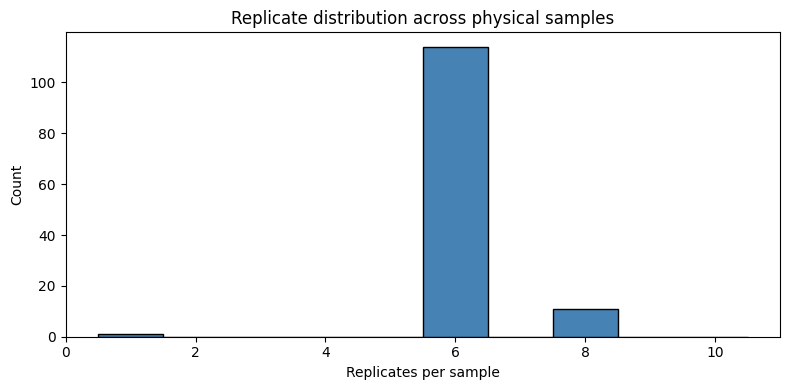

In [8]:
rep_counts = groups.value_counts()

plt.figure(figsize=(8, 4))
plt.hist(rep_counts.values, bins=range(1, 12), edgecolor='black', align='left', color='steelblue')
plt.xlabel('Replicates per sample')
plt.ylabel('Count')
plt.title('Replicate distribution across physical samples')
plt.tight_layout()
plt.show()

Most samples had exactly 6 replicates. Then I checked which sample is having less than 3 replicates. Looking to the sample name, it is probably faulty sample.

In [9]:
low_rep = rep_counts[rep_counts < 3]
print(low_rep)

Sample ID
3056RanBioMixMalarenergi_fault    1
Name: count, dtype: int64


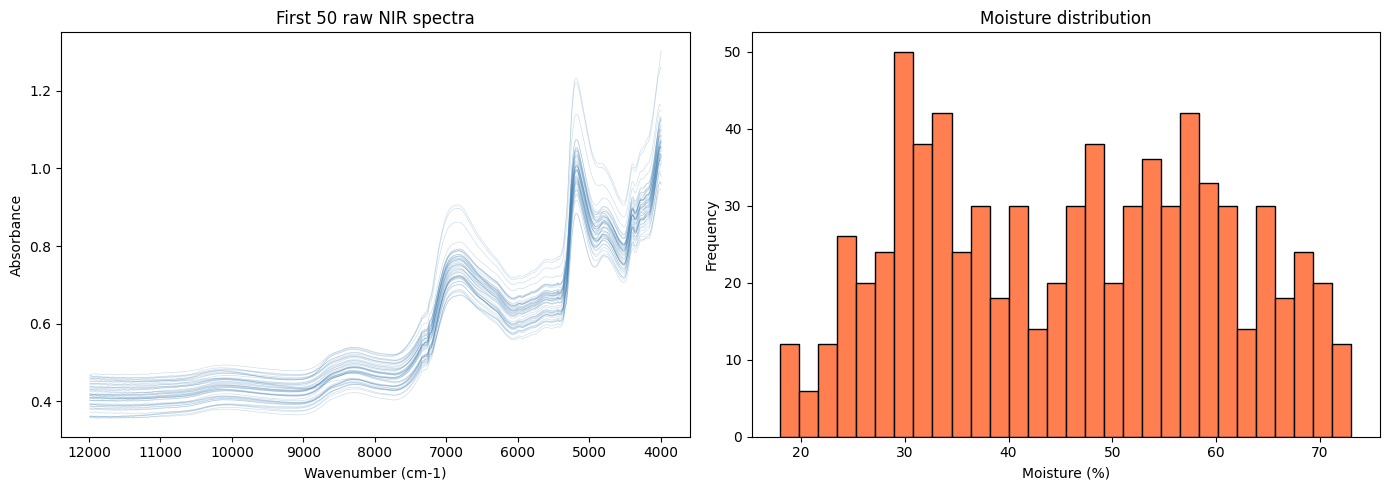

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(wavelengths, X_raw[:50].T, alpha=0.25, lw=0.5, color='steelblue')
axes[0].invert_xaxis()
axes[0].set_xlabel('Wavenumber (cm-1)')
axes[0].set_ylabel('Absorbance')
axes[0].set_title('First 50 raw NIR spectra')

axes[1].hist(y, bins=30, edgecolor='black', color='coral')
axes[1].set_xlabel('Moisture (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Moisture distribution')

plt.tight_layout()
plt.show()

The raw spectra showed the typical NIR absorbance profile, with visible variation between samples. Moisture was spread fairly evenly between 18 and 73 percent, so there was good coverage of the target range.

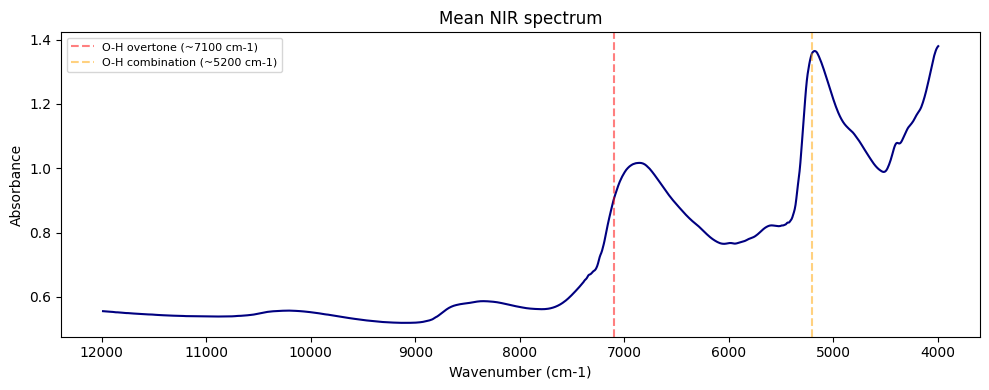

In [11]:
mean_spec = X_raw.mean(axis=0)

plt.figure(figsize=(10, 4))
plt.plot(wavelengths, mean_spec, color='navy', lw=1.5)
plt.axvline(7100, color='red', ls='--', alpha=0.5, label='O-H overtone (~7100 cm-1)')
plt.axvline(5200, color='orange', ls='--', alpha=0.5, label='O-H combination (~5200 cm-1)')
plt.gca().invert_xaxis()
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Absorbance')
plt.title('Mean NIR spectrum')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

I plotted the mean spectrum to see the overall shape without the noise from individual scans. It had two clear peaks related to water. The one around 7100 cm-1 came from the O-H first overtone, and the one around 5200 cm-1 was the O-H combination band. Since both sat inside the 4000-7500 cm-1 range, I kept only that region for modelling and dropped the higher wavenumbers where the signal was mostly noise.

## Outlier Detection

I wanted to find spectra that looked not normal compared to the rest, that is why I decided to standardize the data and ran PCA to compress the spectra into a few key dimensions. Then I calculated a Hotelling T2 score for each spectrum, which basically measures how far it sits from the center of the group. I used the F-distribution to set a 95% confidence cutoff, so any spectrum with a T2 above that line was flagged as an outlier.

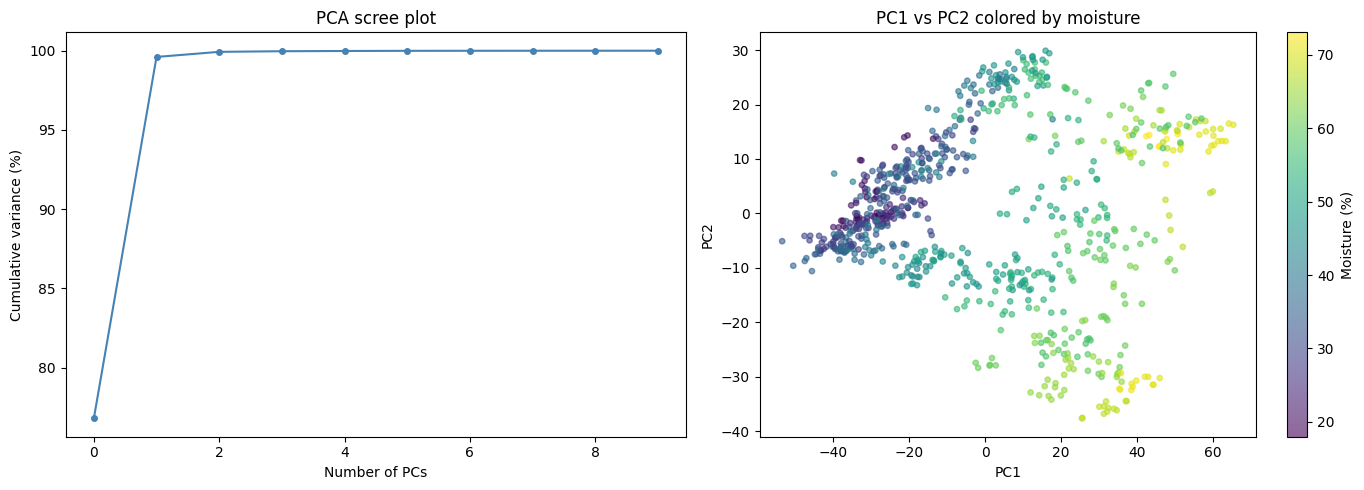

In [12]:
X_scaled = StandardScaler().fit_transform(X_raw)
pca = PCA(n_components=10, random_state=SEED)
scores = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o', ms=4, color='steelblue')
axes[0].set_xlabel('Number of PCs')
axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('PCA scree plot')

sc = axes[1].scatter(scores[:, 0], scores[:, 1], c=y, cmap='viridis', alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[1], label='Moisture (%)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PC1 vs PC2 colored by moisture')

plt.tight_layout()
plt.show()

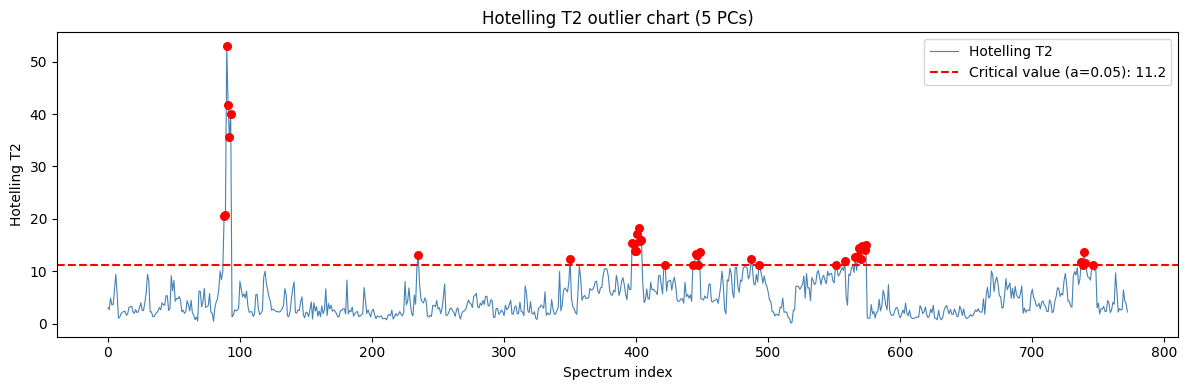

Outliers detected: 39 of 773


In [13]:
n_pcs = 5
n_obs = scores.shape[0]
scores_std = scores[:, :n_pcs] / scores[:, :n_pcs].std(axis=0)
T2 = np.sum(scores_std ** 2, axis=1)

F_crit = f_dist.ppf(0.95, n_pcs, n_obs - n_pcs)
T2_crit = (n_pcs * (n_obs - 1) / (n_obs - n_pcs)) * F_crit
outlier_mask = T2 > T2_crit

plt.figure(figsize=(12, 4))
plt.plot(T2, lw=0.8, color='steelblue', label='Hotelling T2')
plt.axhline(T2_crit, color='red', linestyle='--', label=f'Critical value (a=0.05): {T2_crit:.1f}')
plt.scatter(np.where(outlier_mask)[0], T2[outlier_mask], color='red', zorder=5, s=30)
plt.xlabel('Spectrum index')
plt.ylabel('Hotelling T2')
plt.title('Hotelling T2 outlier chart (5 PCs)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Outliers detected: {outlier_mask.sum()} of {len(T2)}')

In [14]:
fault_mask = groups.apply(lambda g: 'fault' in g.lower()).values
remove_mask = outlier_mask | fault_mask

X_clean = X_raw[~remove_mask]
y_clean = y[~remove_mask]
groups_clean = groups.values[~remove_mask]

The T2 chart flagged 39 spectra above the 95% threshold. I removed those along with the single fault-labelled sample. After cleaning, 733 spectra from 122 physical samples remained for the rest of the analysis.

##  External Holdout Split

Before any modelling or preprocessing, I set aside 13 physical samples as a completely external test set.

In [15]:
unique_grps = np.unique(groups_clean)
rng = np.random.default_rng(SEED)
rng.shuffle(unique_grps)

n_holdout = 13
holdout_grps = set(unique_grps[:n_holdout])

ho_mask = np.array([g in holdout_grps for g in groups_clean])
tv_mask = ~ho_mask

X_tv_raw = X_clean[tv_mask]
y_tv = y_clean[tv_mask]
groups_tv = groups_clean[tv_mask]

X_ho_raw = X_clean[ho_mask]
y_ho = y_clean[ho_mask]

print(f'Train/val: {X_tv_raw.shape[0]} spectra from {len(np.unique(groups_tv))} samples')
print(f'Holdout:   {X_ho_raw.shape[0]} spectra from {n_holdout} samples')

Train/val: 651 spectra from 109 samples
Holdout:   82 spectra from 13 samples


## Preprocessing

Raw spectra can be noisy and shifted, so I tried cleaning them up before modelling. I tested three scatter correction methods (raw, SNV, MSC) combined with four smoothing or derivative options (none, smoothing, first derivative, second derivative). That gave 12 combinations in total. Derivatives help sharpen peaks that are hard to see in the raw signal. I applied everything only to the 4000-7500 cm-1 region since that is where the moisture-related bands were.

In [16]:
def preprocess(X, scatter='raw', sg=None, ref_msc=None):
    if scatter == 'SNV':
        Xp = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)
    elif scatter == 'MSC':
        ref = ref_msc if ref_msc is not None else X.mean(axis=0)
        coeffs = np.array([np.polyfit(ref, x, 1) for x in X])
        Xp = (X - coeffs[:, 1:2]) / coeffs[:, 0:1]
    else:
        Xp = X.copy()

    if sg == 'smooth':
        Xp = savgol_filter(Xp, window_length=15, polyorder=3, deriv=0)
    elif sg == 'd1':
        Xp = savgol_filter(Xp, window_length=15, polyorder=3, deriv=1)
    elif sg == 'd2':
        Xp = savgol_filter(Xp, window_length=15, polyorder=3, deriv=2)

    return Xp

In [17]:
region_mask = (wavelengths >= 4000) & (wavelengths <= 7500)
wavelengths_sel = wavelengths[region_mask]
msc_ref = X_tv_raw.mean(axis=0)

scatter_methods = ['raw', 'SNV', 'MSC']
sg_options = [None, 'smooth', 'd1', 'd2']
sg_labels = {None: 'none', 'smooth': 'SG-s', 'd1': 'SG-d1', 'd2': 'SG-d2'}

combos_tv = {}
combos_ho = {}
for sc in scatter_methods:
    ref = msc_ref if sc == 'MSC' else None
    for sg in sg_options:
        key = f'{sc}+{sg_labels[sg]}'
        combos_tv[key] = preprocess(X_tv_raw, scatter=sc, sg=sg, ref_msc=ref)[:, region_mask]
        combos_ho[key] = preprocess(X_ho_raw, scatter=sc, sg=sg, ref_msc=ref)[:, region_mask]

print(f'Preprocessing combinations: {len(combos_tv)}')
print(f'Features per combo: {list(combos_tv.values())[0].shape[1]}')

Preprocessing combinations: 12
Features per combo: 454


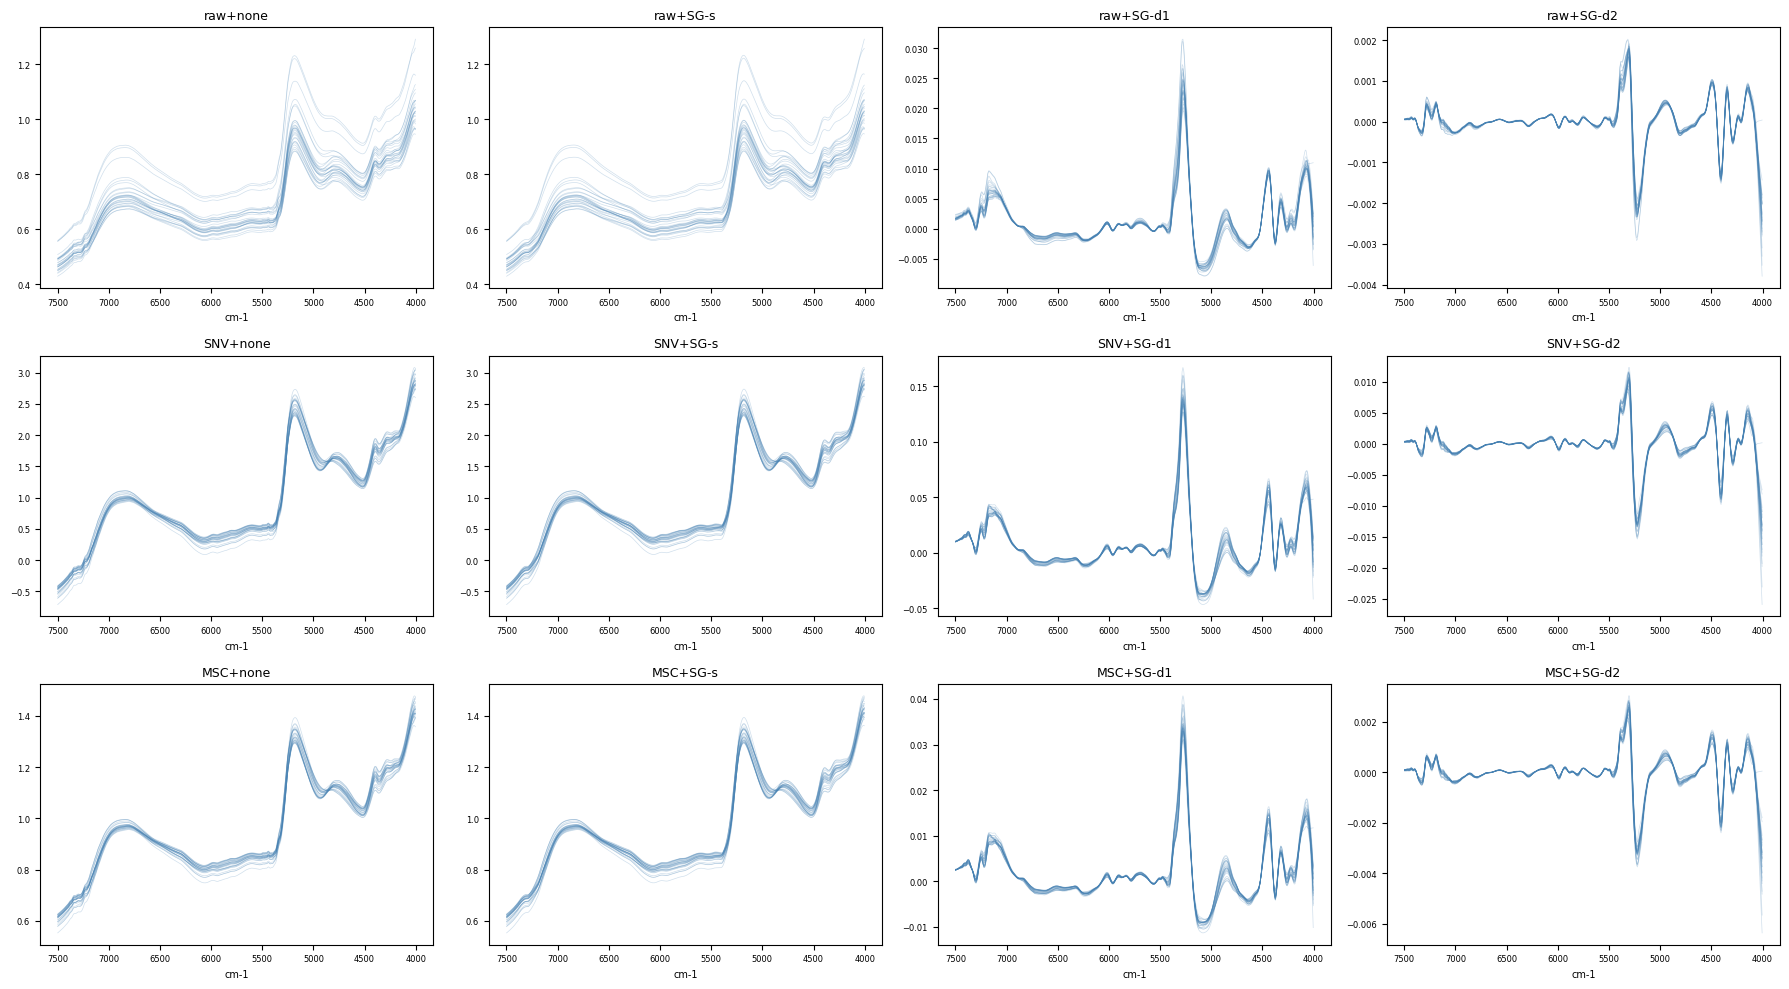

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, X_pp) in zip(axes, combos_tv.items()):
    ax.plot(wavelengths_sel, X_pp[:30].T, alpha=0.25, lw=0.5, color='steelblue')
    ax.set_title(name, fontsize=9)
    ax.invert_xaxis()
    ax.tick_params(labelsize=6)
    ax.set_xlabel('cm-1', fontsize=7)

plt.tight_layout()
plt.show()

Looking at the plots, SNV and MSC made the spectra line up much better by removing the shifts between them. The derivatives helped sharpen the peaks but the second derivative also brought in more noise.

## Modelling

I tried three different models to predict moisture from the spectra. All of them used grouped 5-fold cross-validation, meaning each fold held out entire physical samples so that replicates of the same sample never ended up in both train and test.

In [19]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate(y_true, y_pred):
    r = rmse(y_true, y_pred)
    return {
        'RMSE': round(r, 4),
        'R2':   round(r2_score(y_true, y_pred), 4),
        'RPD':  round(float(y_true.std()) / r, 4)
    }

outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=5)

### PLSR

I tested PLSR on all 12 preprocessing combinations to find the best one.

In [20]:
plsr_results = {}

for pp_name, X_tv in combos_tv.items():
    outer_preds = np.zeros(len(y_tv))

    for train_idx, val_idx in outer_cv.split(X_tv, y_tv, groups_tv):
        X_tr, X_val = X_tv[train_idx], X_tv[val_idx]
        y_tr = y_tv[train_idx]

        best_nc, best_ri = 1, np.inf
        for nc in range(1, 21):
            pls = PLSRegression(n_components=nc, max_iter=500)
            ip = cross_val_predict(pls, X_tr, y_tr, cv=inner_cv, groups=groups_tv[train_idx])
            ri = rmse(y_tr, ip)
            if ri < best_ri:
                best_ri, best_nc = ri, nc

        pls = PLSRegression(n_components=best_nc, max_iter=500)
        pls.fit(X_tr, y_tr)
        outer_preds[val_idx] = pls.predict(X_val).ravel()

    plsr_results[pp_name] = evaluate(y_tv, outer_preds)
    plsr_results[pp_name]['preds'] = outer_preds
    print(pp_name, f'RMSECV={plsr_results[pp_name]["RMSE"]:.3f}  R2={plsr_results[pp_name]["R2"]:.3f}  RPD={plsr_results[pp_name]["RPD"]:.3f}')

raw+none RMSECV=3.035  R2=0.954  RPD=4.641
raw+SG-s RMSECV=3.006  R2=0.954  RPD=4.685
raw+SG-d1 RMSECV=3.250  R2=0.947  RPD=4.333
raw+SG-d2 RMSECV=3.194  R2=0.949  RPD=4.409
SNV+none RMSECV=2.635  R2=0.965  RPD=5.346
SNV+SG-s RMSECV=2.649  R2=0.965  RPD=5.316
SNV+SG-d1 RMSECV=2.866  R2=0.959  RPD=4.914
SNV+SG-d2 RMSECV=2.831  R2=0.960  RPD=4.974
MSC+none RMSECV=2.732  R2=0.962  RPD=5.156
MSC+SG-s RMSECV=2.754  R2=0.962  RPD=5.115
MSC+SG-d1 RMSECV=2.946  R2=0.956  RPD=4.781
MSC+SG-d2 RMSECV=2.948  R2=0.956  RPD=4.777


In [21]:
plsr_df = pd.DataFrame(
    {k: {m: v for m, v in plsr_results[k].items() if m != 'preds'} for k in plsr_results}
).T.astype(float).sort_values('RMSE')

print(plsr_df.to_string())

best_pp = plsr_df.index[0]
outer_preds_plsr = plsr_results[best_pp]['preds']
X_tv_best = combos_tv[best_pp]
X_ho_best = combos_ho[best_pp]

print(f'\nBest preprocessing: {best_pp}')

             RMSE      R2     RPD
SNV+none   2.6347  0.9650  5.3456
SNV+SG-s   2.6491  0.9646  5.3165
MSC+none   2.7316  0.9624  5.1559
MSC+SG-s   2.7537  0.9618  5.1147
SNV+SG-d2  2.8314  0.9596  4.9742
SNV+SG-d1  2.8662  0.9586  4.9139
MSC+SG-d1  2.9456  0.9563  4.7814
MSC+SG-d2  2.9482  0.9562  4.7772
raw+SG-s   3.0065  0.9544  4.6846
raw+none   3.0347  0.9536  4.6411
raw+SG-d2  3.1942  0.9486  4.4093
raw+SG-d1  3.2504  0.9467  4.3330

Best preprocessing: SNV+none


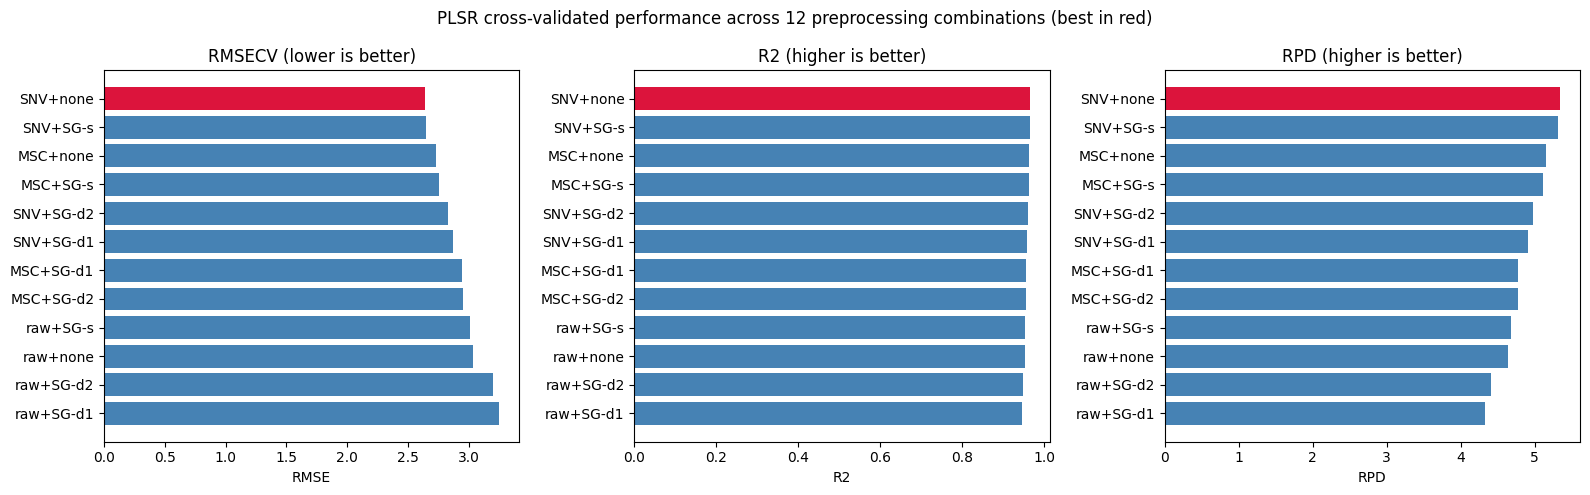

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_list = ['RMSE', 'R2', 'RPD']
titles_list = ['RMSECV (lower is better)', 'R2 (higher is better)', 'RPD (higher is better)']

for ax, metric, title in zip(axes, metrics_list, titles_list):
    colors = ['crimson' if i == 0 else 'steelblue' for i in range(len(plsr_df))]
    ax.barh(plsr_df.index, plsr_df[metric], color=colors)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.set_xlabel(metric)

plt.suptitle('PLSR cross-validated performance across 12 preprocessing combinations (best in red)')
plt.tight_layout()
plt.show()

### SVR

Next I tried Support Vector Regression with an RBF kernel. Since SVR needs the input features to be on the same scale, I added a StandardScaler step before it. The inner CV loop tried different combinations of C and epsilon to find what worked best.

In [23]:
param_grid = [{'C': C, 'epsilon': e} for C in [0.1, 1, 10, 100] for e in [0.1, 0.5]]
outer_preds_svr = np.zeros(len(y_tv))

for train_idx, val_idx in outer_cv.split(X_tv_best, y_tv, groups_tv):
    X_tr, X_val = X_tv_best[train_idx], X_tv_best[val_idx]
    y_tr = y_tv[train_idx]

    best_p, best_ri = None, np.inf
    for p in param_grid:
        pipe = Pipeline([('sc', StandardScaler()), ('svr', SVR(kernel='rbf', **p))])
        ip = cross_val_predict(pipe, X_tr, y_tr, cv=inner_cv, groups=groups_tv[train_idx])
        ri = rmse(y_tr, ip)
        if ri < best_ri:
            best_ri, best_p = ri, p

    pipe_f = Pipeline([('sc', StandardScaler()), ('svr', SVR(kernel='rbf', **best_p))])
    pipe_f.fit(X_tr, y_tr)
    outer_preds_svr[val_idx] = pipe_f.predict(X_val)

svr_metrics = evaluate(y_tv, outer_preds_svr)
print('SVR CV:', svr_metrics)

SVR CV: {'RMSE': np.float64(3.0606), 'R2': 0.9528, 'RPD': np.float64(4.6018)}


SVR got an RMSECV of 3.20, which was worse than PLSR. Even though SVR can capture nonlinear patterns, it did not help here. The relationship between the spectra and moisture was already close to linear, so the extra flexibility was not needed.

### ANN

Finally I tried a neural network using sklearn's MLPRegressor. I tested three different layer architectures and used early stopping to avoid overfitting. Same nested grouped CV as before.

In [24]:
architectures = [(256, 64), (128, 64, 32), (256, 128, 64)]
outer_preds_ann = np.zeros(len(y_tv))

for train_idx, val_idx in outer_cv.split(X_tv_best, y_tv, groups_tv):
    X_tr, X_val = X_tv_best[train_idx], X_tv_best[val_idx]
    y_tr = y_tv[train_idx]

    best_arch, best_ri = None, np.inf
    for arch in architectures:
        pipe = Pipeline([
            ('sc', StandardScaler()),
            ('mlp', MLPRegressor(
                hidden_layer_sizes=arch, activation='relu',
                max_iter=500, early_stopping=True,
                validation_fraction=0.1, random_state=SEED
            ))
        ])
        ip = cross_val_predict(pipe, X_tr, y_tr, cv=inner_cv, groups=groups_tv[train_idx])
        ri = rmse(y_tr, ip)
        if ri < best_ri:
            best_ri, best_arch = ri, arch

    pipe_f = Pipeline([
        ('sc', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=best_arch, activation='relu',
            max_iter=500, early_stopping=True,
            validation_fraction=0.1, random_state=SEED
        ))
    ])
    pipe_f.fit(X_tr, y_tr)
    outer_preds_ann[val_idx] = pipe_f.predict(X_val)

ann_metrics = evaluate(y_tv, outer_preds_ann)
print('ANN CV:', ann_metrics)

ANN CV: {'RMSE': np.float64(3.9326), 'R2': 0.922, 'RPD': np.float64(3.5814)}


The neural network was the weakest with an RMSECV of 3.81. With only a few hundred training samples, there was not enough data for the network to learn anything better than what PLSR already captured.

## Holdout Evaluation

In [25]:
inner_cv_f = GroupKFold(n_splits=5)

best_nc_f, best_ri = 1, np.inf
for nc in range(1, 21):
    pls = PLSRegression(n_components=nc, max_iter=500)
    ip = cross_val_predict(pls, X_tv_best, y_tv, cv=inner_cv_f, groups=groups_tv)
    ri = rmse(y_tv, ip)
    if ri < best_ri:
        best_ri, best_nc_f = ri, nc

print(f'Final PLSR n_components: {best_nc_f}')
plsr_f = PLSRegression(n_components=best_nc_f, max_iter=500)
plsr_f.fit(X_tv_best, y_tv)
y_pred_plsr_ho = plsr_f.predict(X_ho_best).ravel()
print('PLSR holdout:', evaluate(y_ho, y_pred_plsr_ho))

Final PLSR n_components: 20
PLSR holdout: {'RMSE': np.float64(2.6693), 'R2': 0.9547, 'RPD': np.float64(4.6962)}


In [26]:
best_svr_f, best_ri = None, np.inf
for p in param_grid:
    pipe = Pipeline([('sc', StandardScaler()), ('svr', SVR(kernel='rbf', **p))])
    ip = cross_val_predict(pipe, X_tv_best, y_tv, cv=inner_cv_f, groups=groups_tv)
    ri = rmse(y_tv, ip)
    if ri < best_ri:
        best_ri, best_svr_f = ri, p

svr_f = Pipeline([('sc', StandardScaler()), ('svr', SVR(kernel='rbf', **best_svr_f))])
svr_f.fit(X_tv_best, y_tv)
y_pred_svr_ho = svr_f.predict(X_ho_best)

best_arch_f, best_ri = None, np.inf
for arch in architectures:
    pipe = Pipeline([
        ('sc', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=arch, activation='relu',
            max_iter=500, early_stopping=True, random_state=SEED
        ))
    ])
    ip = cross_val_predict(pipe, X_tv_best, y_tv, cv=inner_cv_f, groups=groups_tv)
    ri = rmse(y_tv, ip)
    if ri < best_ri:
        best_ri, best_arch_f = ri, arch

ann_f = Pipeline([
    ('sc', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=best_arch_f, activation='relu',
        max_iter=500, early_stopping=True, random_state=SEED
    ))
])
ann_f.fit(X_tv_best, y_tv)
y_pred_ann_ho = ann_f.predict(X_ho_best)

print('SVR holdout:', evaluate(y_ho, y_pred_svr_ho))
print('ANN holdout:', evaluate(y_ho, y_pred_ann_ho))

SVR holdout: {'RMSE': np.float64(3.2025), 'R2': 0.9347, 'RPD': np.float64(3.9143)}
ANN holdout: {'RMSE': np.float64(3.5124), 'R2': 0.9215, 'RPD': np.float64(3.5689)}


## Results

In [27]:
cv_results = {
    'PLSR': {k: v for k, v in plsr_results[best_pp].items() if k != 'preds'},
    'SVR':  svr_metrics,
    'ANN':  ann_metrics,
}
ho_results = {
    'PLSR': evaluate(y_ho, y_pred_plsr_ho),
    'SVR':  evaluate(y_ho, y_pred_svr_ho),
    'ANN':  evaluate(y_ho, y_pred_ann_ho),
}

rows = []
for model in ['PLSR', 'SVR', 'ANN']:
    cv = cv_results[model]
    ho = ho_results[model]
    rows.append({
        'Model': model,
        'CV RMSE': cv['RMSE'], 'CV R2': cv['R2'], 'CV RPD': cv['RPD'],
        'HO RMSE': ho['RMSE'], 'HO R2': ho['R2'], 'HO RPD': ho['RPD']
    })

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())

       CV RMSE   CV R2  CV RPD  HO RMSE   HO R2  HO RPD
Model                                                  
PLSR    2.6347  0.9650  5.3456   2.6693  0.9547  4.6962
SVR     3.0606  0.9528  4.6018   3.2025  0.9347  3.9143
ANN     3.9326  0.9220  3.5814   3.5124  0.9215  3.5689


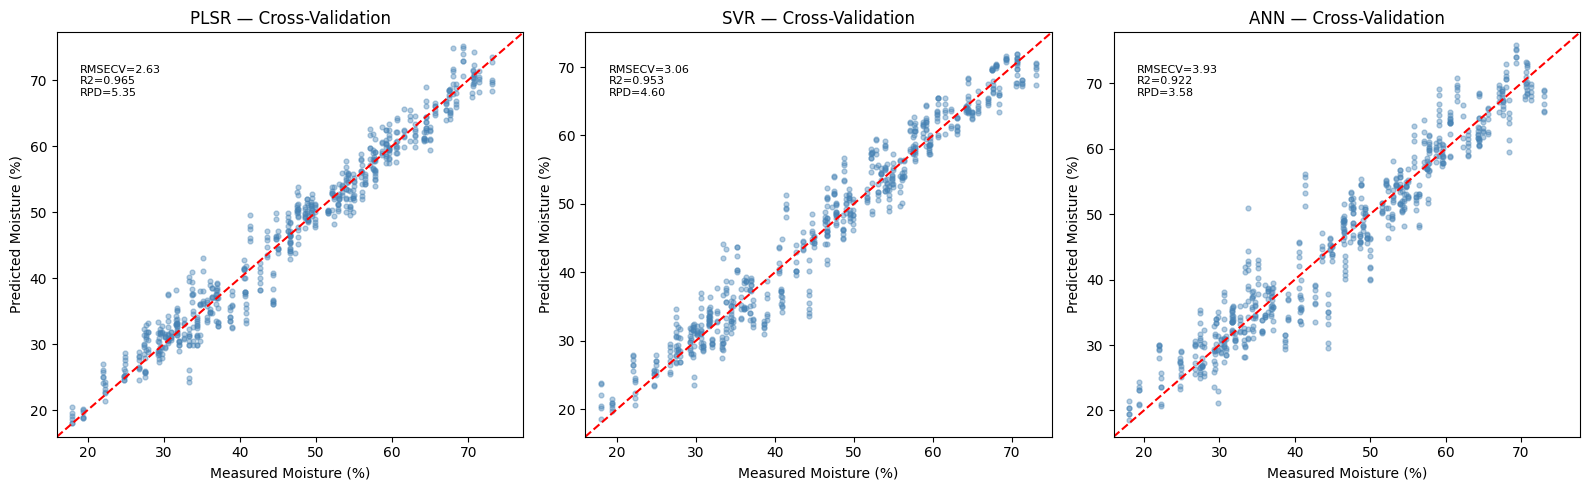

In [28]:
model_names = ['PLSR', 'SVR', 'ANN']
preds_cv = [outer_preds_plsr, outer_preds_svr, outer_preds_ann]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name, preds in zip(axes, model_names, preds_cv):
    ax.scatter(y_tv, preds, alpha=0.4, s=12, color='steelblue')
    lims = [min(y_tv.min(), preds.min()) - 2, max(y_tv.max(), preds.max()) + 2]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    m = evaluate(y_tv, preds)
    ax.text(0.05, 0.92, f'RMSECV={m["RMSE"]:.2f}\nR2={m["R2"]:.3f}\nRPD={m["RPD"]:.2f}',
            transform=ax.transAxes, fontsize=8, va='top')
    ax.set_xlabel('Measured Moisture (%)')
    ax.set_ylabel('Predicted Moisture (%)')
    ax.set_title(f'{name} — Cross-Validation')

plt.tight_layout()
plt.show()

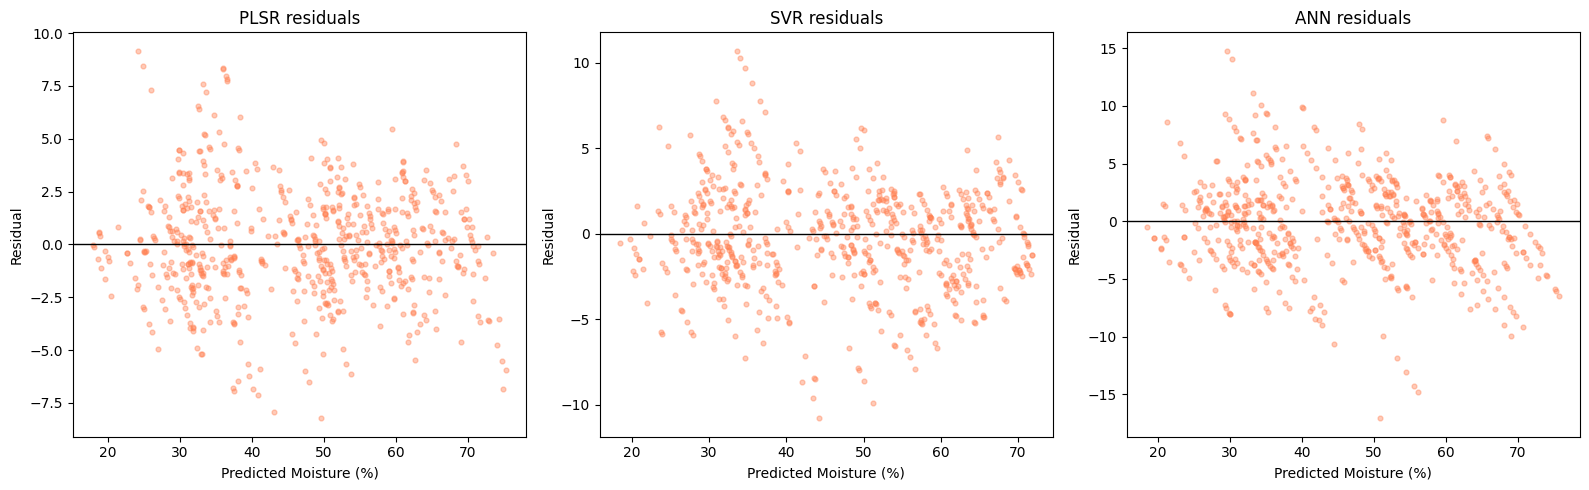

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name, preds in zip(axes, model_names, preds_cv):
    residuals = y_tv - preds
    ax.scatter(preds, residuals, alpha=0.4, s=12, color='coral')
    ax.axhline(0, color='black', lw=1)
    ax.set_xlabel('Predicted Moisture (%)')
    ax.set_ylabel('Residual')
    ax.set_title(f'{name} residuals')

plt.tight_layout()
plt.show()

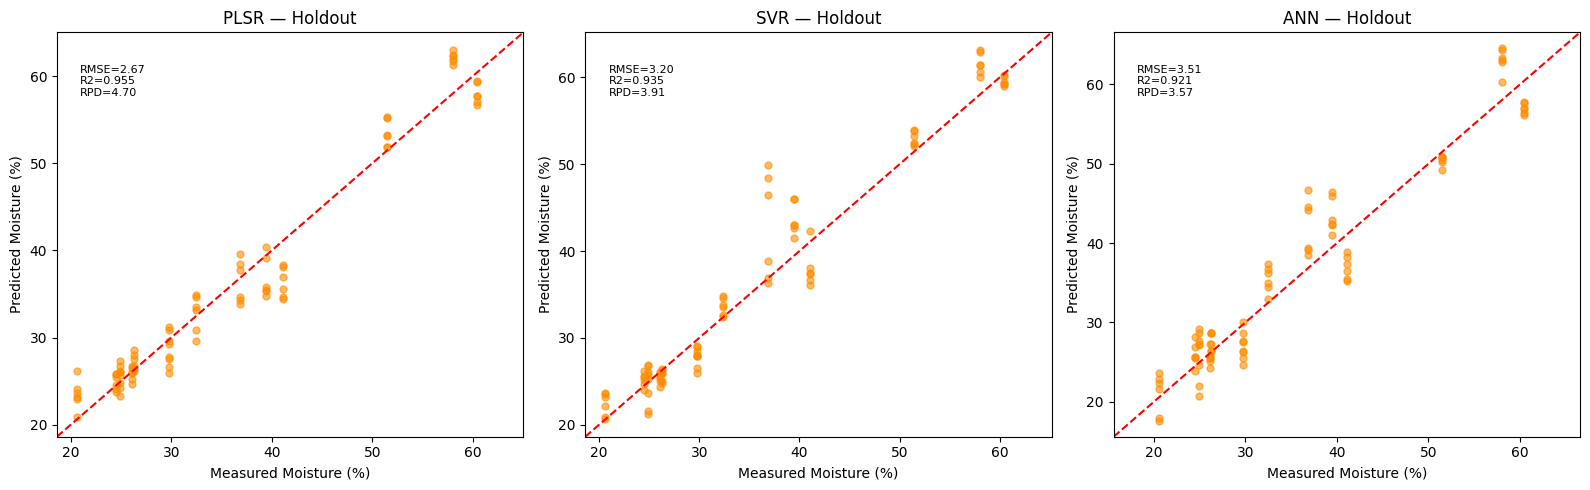

In [30]:
preds_ho = [y_pred_plsr_ho, y_pred_svr_ho, y_pred_ann_ho]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name, preds in zip(axes, model_names, preds_ho):
    ax.scatter(y_ho, preds, alpha=0.6, s=25, color='darkorange')
    lims = [min(y_ho.min(), preds.min()) - 2, max(y_ho.max(), preds.max()) + 2]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    m = evaluate(y_ho, preds)
    ax.text(0.05, 0.92, f'RMSE={m["RMSE"]:.2f}\nR2={m["R2"]:.3f}\nRPD={m["RPD"]:.2f}',
            transform=ax.transAxes, fontsize=8, va='top')
    ax.set_xlabel('Measured Moisture (%)')
    ax.set_ylabel('Predicted Moisture (%)')
    ax.set_title(f'{name} — Holdout')

plt.tight_layout()
plt.show()

PLSR was the best model overall, both in cross-validation and on the holdout.

### Repeatability Analysis

Since each holdout sample had multiple scans, I checked how stable the predictions were across those scans. For each sample, I calculated the standard deviation of its replicate predictions. If the SD is low, it means the model gives consistent results no matter which scan you feed it.

In [31]:
groups_ho = groups_clean[ho_mask]

ho_preds_dict = {'PLSR': y_pred_plsr_ho, 'SVR': y_pred_svr_ho, 'ANN': y_pred_ann_ho}
repeat_rows = []

for model_name, preds in ho_preds_dict.items():
    df_rep = pd.DataFrame({'group': groups_ho, 'pred': preds})
    sample_sd = df_rep.groupby('group')['pred'].std()
    repeat_rows.append({
        'Model': model_name,
        'Mean within-sample SD': round(sample_sd.mean(), 3),
        'Median within-sample SD': round(sample_sd.median(), 3),
        'Max within-sample SD': round(sample_sd.max(), 3)
    })

repeat_df = pd.DataFrame(repeat_rows).set_index('Model')
print(repeat_df.to_string())

       Mean within-sample SD  Median within-sample SD  Max within-sample SD
Model                                                                      
PLSR                   1.495                    1.518                 2.415
SVR                    1.575                    1.091                 6.144
ANN                    1.746                    1.539                 3.480


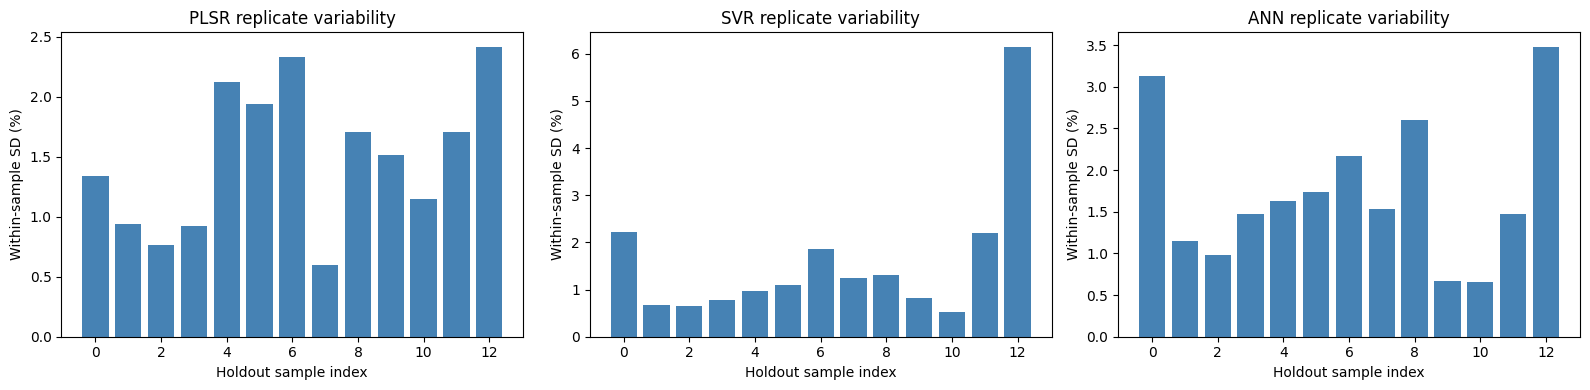

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, preds) in zip(axes, ho_preds_dict.items()):
    df_rep = pd.DataFrame({'group': groups_ho, 'pred': preds})
    sample_sd = df_rep.groupby('group')['pred'].std()
    ax.bar(range(len(sample_sd)), sample_sd.values, color='steelblue')
    ax.set_xlabel('Holdout sample index')
    ax.set_ylabel('Within-sample SD (%)')
    ax.set_title(f'{model_name} replicate variability')

plt.tight_layout()
plt.show()

PLSR had the lowest variability across replicates, meaning its predictions were the most stable. The neural network jumped around the most, which makes sense because small differences in the input get increased through its layers.

### Prediction Intervals

Then I looked at how wrong the model was during cross-validation, measured the spread of those errors, and used that to build a range around each prediction. If the errors follow a bell-shaped distribution, 95% of them fall within 1.96 standard deviations from the mean, so multiplying the error SD by 1.96 gives a band where 95% of true values should land.

In [33]:
cv_preds_dict = {'PLSR': outer_preds_plsr, 'SVR': outer_preds_svr, 'ANN': outer_preds_ann}

pi_rows = []
for model_name, preds in cv_preds_dict.items():
    residuals = y_tv - preds
    sigma = residuals.std()
    half_width = 1.96 * sigma
    pi_rows.append({
        'Model': model_name,
        'Residual SD': round(sigma, 3),
        '95% PI half-width': round(half_width, 3)
    })

pi_df = pd.DataFrame(pi_rows).set_index('Model')
print(pi_df.to_string())

       Residual SD  95% PI half-width
Model                                
PLSR         2.635              5.164
SVR          3.046              5.971
ANN          3.929              7.701


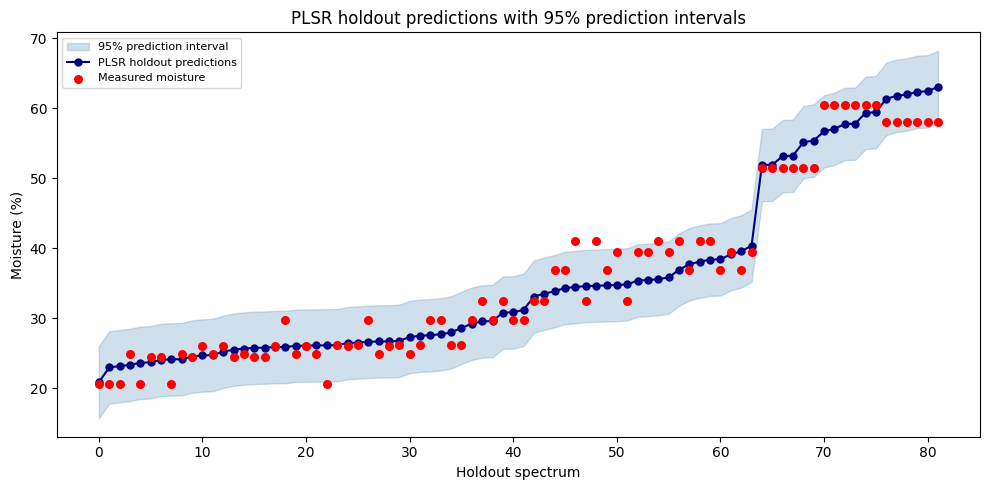

In [34]:
plsr_resid_sd = (y_tv - outer_preds_plsr).std()
plsr_hw = 1.96 * plsr_resid_sd

sort_idx = np.argsort(y_pred_plsr_ho)
y_ho_sorted = y_pred_plsr_ho[sort_idx]

plt.figure(figsize=(10, 5))
plt.fill_between(range(len(y_ho_sorted)),
                 y_ho_sorted - plsr_hw, y_ho_sorted + plsr_hw,
                 alpha=0.25, color='steelblue', label='95% prediction interval')
plt.plot(y_ho_sorted, 'o-', ms=5, color='navy', label='PLSR holdout predictions')
plt.scatter(range(len(y_ho_sorted)), y_ho[sort_idx], color='red',
            s=30, zorder=5, label='Measured moisture')
plt.xlabel('Holdout spectrum')
plt.ylabel('Moisture (%)')
plt.title('PLSR holdout predictions with 95% prediction intervals')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

For PLSR, the 95% interval was about plus or minus 5.3 percentage points. So if the model predicts 45% moisture, the true value is likely between 40 and 50 percent. Most of the holdout measurements landed inside the band, which means the interval estimate worked well.

## Conclusion

I tested three models (PLSR, SVR, and a neural network) for predicting moisture from NIR spectra of biomass. After removing outliers, I had 733 spectra from 122 samples. I used grouped cross-validation to make sure replicates of the same sample stayed together, otherwise the results would look better than they really are. Out of everything I tried, SNV preprocessing worked best, and PLSR gave the lowest error with an RMSECV of 2.69 and R2 of 0.96, also it was the most consistent when predicting different scans of the same sample. SVR and the neural network did not beat PLSR, likely because the data was limited and the relationship was already mostly linear.